# 설계 강건성 최적화

메타 컬러필터가 0.5μm 크기 픽셀에 적용되기 위해서는 fabrication error에 대한 강건성이 필수적임. 본 연구에서는 메타 컬러필터의 디자인에 5nm의 공정 오차(공정 마진)가 생길 시 최종 optical efficiency가 감소하는 상대적 비율을 계산하고, 이를 관심 파장대역(400nm-700nm)에서 정량적 지표로 이용함. 또한 color uniformity 열화를 제한하기 위해 공정 오차에 의한 R, G, B 서브픽셀 간의 광효율 감소량 차이를 15% 이내로 제한함. 공정 오차는 설계 가능 영역의 시뮬레이션상의 픽셀에 임의(random)로 구조물을 추가(inclusion)하거나 빼는 (eroded) 방식으로 표현하고 이를 최종결과물의 결과와 비교함. 공정이 가능한 경우 (수요 기업이 있거나, 최첨단 음각 장비를 제공하는 기업이 있는 경우), 본 연구과제의 최종 결과물과 제작된 결과물의 오차를 비교 제시함.

모듈 입력

In [1]:
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product
import nlopt
from matplotlib import pyplot as plt

# 시뮬레이션 환경 설정
mp.verbosity(0)
um_scale = 2  # 1A = 0.5 um
seed = 240  # 재현성을 위한 난수 시드 고정
np.random.seed(seed)

# 물질 정의
Air = mp.Medium(index=1.0)
SiN = mp.Medium(epsilon=4)
SiO2 = mp.Medium(epsilon=2.1)
SiPD = mp.Medium(epsilon=9)

Basic setup

In [2]:
# 시뮬레이션 해상도 및 공간 설정
resolution = 25  # 해상도 설정

design_region_width = 3  # 디자인 영역 너비 (1.5 um)
design_region_height = 4  # 디자인 영역 높이 (2 um)
pml_size = 1  # PML 영역 크기 (0.5 um)
pml_layers = [mp.PML(thickness=pml_size, direction=mp.Y)]  # PML 설정

# 시뮬레이션 공간 크기 설정
Sx = design_region_width  # x축 크기 (1.5 um)
Sy = 2 * pml_size + design_region_height + 2  # y축 크기 (3 um)
cell_size = mp.Vector3(Sx, Sy)  # 시뮬레이션 셀 크기 설정

# 파장 및 주파수 설정
wavelengths = np.array([0.43 * um_scale, 0.45 * um_scale, 0.47 * um_scale, 
                        0.53 * um_scale, 0.55 * um_scale, 0.57 * um_scale, 
                        0.62 * um_scale, 0.65 * um_scale, 0.68 * um_scale])
frequencies = 1 / wavelengths
nf = len(frequencies)  # frequency 개수

# 제작 공정 제약 설정
minimum_length = 0.08  # 최소 feature 크기 (40 nm)
eta_i = 0.5  # intermediate design 필드 임계값
eta_e = 0.55  # erosion design 필드 임계값
eta_d = 1 - eta_e  # dilation design 필드 임계값
filter_radius = mpa.get_conic_radius_from_eta_e(minimum_length, 0.75)  # 필터 반지름
design_region_resolution = int(resolution)  # 디자인 영역 해상도

# 소스 설정
width = 2
frequency = 1 / (0.550 * um_scale)
fwidth = frequency * width
src = mp.GaussianSource(frequency=frequency, fwidth=fwidth, is_integrated=True)

source_center = [0, Sy / 2 - pml_size - 0.5, 0]  # 소스 위치
source_size = mp.Vector3(Sx, 0, 0)  # 소스 크기

src_0 = mp.GaussianSource(frequency=frequency, fwidth=fwidth, is_integrated=True)  # 소스 설정
k_point_0 = mp.Vector3(y=-1).rotate(mp.Vector3(z=1), 0)  # k-point 설정 (입사각 0도)

# EigenMode 소스 설정
source0 = [mp.EigenModeSource(src=src_0,
                              center=source_center,
                              size=source_size,
                              direction=mp.AUTOMATIC,
                              eig_kpoint=k_point_0,
                              eig_band=1,
                              eig_parity=mp.EVEN_Y + mp.ODD_Z,
                              eig_match_freq=True)]

# 설계 영역 설정
Nx = int(round(design_region_resolution * design_region_width)) + 1
Ny = int(round(design_region_resolution * design_region_height)) + 1
design_variables = mp.MaterialGrid(mp.Vector3(Nx, Ny), SiO2, SiN, grid_type="U_MEAN")
design_region = mpa.DesignRegion(
    design_variables, 
    volume=mp.Volume(center=mp.Vector3(0, 0, 0), 
    size=mp.Vector3(design_region_width, design_region_height, 0)
    )
)

# 필터 및 프로젝션 함수 정의
def mapping(x, eta, beta):
    # 필터 및 프로젝션 수행
    x = x.flatten()
    filtered_field = mpa.conic_filter(
        x, 
        filter_radius, 
        design_region_width, 
        design_region_height, 
        design_region_resolution
        )
    
    projected_field = mpa.tanh_projection(filtered_field, beta, eta)

    return projected_field.flatten()

# 시뮬레이션 설정 및 블록 정의
geometry = [
    mp.Block(
        center=design_region.center, 
        size=design_region.size, 
        material=design_variables
        ),
    mp.Block(
        center=mp.Vector3(0, -3, 0), 
        size=mp.Vector3(Sx, 2, 0), 
        material=SiPD
        )
]

Normalized simulation

<Axes: xlabel='X', ylabel='Y'>

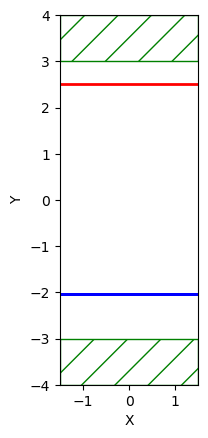

In [3]:
# Normalization flux 계산을 위한 시뮬레이션 설정
sim = mp.Simulation(
    cell_size=cell_size, 
    boundary_layers=pml_layers, 
    sources=source0, 
    default_material=Air, 
    resolution=resolution, 
    k_point=k_point_0
)

# 각 주파수에서 필드 추가 및 계산
# DFT fields 계산
tran_Ez = [sim.add_dft_fields([mp.Ez], frequencies[i], 0, 1, center=mp.Vector3(0, -2 - 1/resolution, 0), size=mp.Vector3(Sx, 0, 0), yee_grid=True) for i in range(9)]
sim.run(until_after_sources=mp.stop_when_dft_decayed(1e-6))

# DFT array 계산
dft_array_Ez = [np.sum(np.abs(sim.get_dft_array(tran_Ez[i], mp.Ez, 0)) ** 2) for i in range(9)]

sim.plot2D()


Optimization Settings

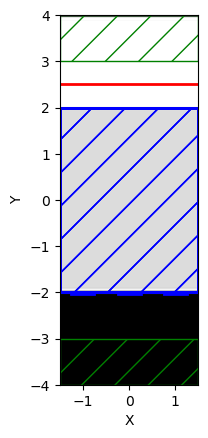

In [4]:
# Meep simulation 세팅
sim = mp.Simulation(
    cell_size=cell_size, 
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source0,
    default_material=Air, # 빈공간
    resolution=resolution,
    k_point = k_point_0 # bloch boundary
)

# 모니터 위치와 크기 설정 (focal point)
monitor_position_R = mp.Vector3(-1, -2 - 1/resolution)
monitor_position_G = mp.Vector3(0, -2 - 1/resolution)
monitor_position_B = mp.Vector3(1, -2 - 1/resolution)
monitor_size = mp.Vector3(0.5,0) 

# FourierFields를 통해 monitor_position에서 monitor_size만큼의 영역에 대한 Fourier transform을 구함
FourierFields_R = mpa.FourierFields(sim,mp.Volume(center=monitor_position_R,size=monitor_size),mp.Ez,yee_grid=True)
FourierFields_G = mpa.FourierFields(sim,mp.Volume(center=monitor_position_G,size=monitor_size),mp.Ez,yee_grid=True)
FourierFields_B = mpa.FourierFields(sim,mp.Volume(center=monitor_position_B,size=monitor_size),mp.Ez,yee_grid=True)
ob_list = [FourierFields_R, FourierFields_G, FourierFields_B]

# J : Objective function
# FourierFields가 측정한 필드, 모니터의 중심에서 Ez 구성요소의 절댓값을 제곱한 값을 취한 후 평균을 계산하여 평균 강도를 계산
# [frequency index, moniter index]
def J(fields_R, fields_G, fields_B):

    blue = npa.mean(npa.sum((npa.abs(fields_B[0:3, :])) ** 2) / dft_array_Ez[0:3])
    green = npa.mean(npa.sum((npa.abs(fields_G[3:6, :])) ** 2) / dft_array_Ez[3:6])
    red = npa.mean(npa.sum((npa.abs(fields_R[6:9, :])) ** 2) / dft_array_Ez[6:9])
    
    return 3 - (blue + green + red)

# 최적화 설정
opt_o = mpa.OptimizationProblem(
    simulation=sim,
    objective_functions=[J],
    objective_arguments=ob_list,
    design_regions=[design_region],
    frequencies=frequencies,
    decay_by=1e-3, # 모니터에 남아있는 필드 값의 비율
)
opt_d = mpa.OptimizationProblem(
    simulation=sim,
    objective_functions=[J],
    objective_arguments=ob_list,
    design_regions=[design_region],
    frequencies=frequencies,
    decay_by=1e-3, # 모니터에 남아있는 필드 값의 비율
)
opt_e = mpa.OptimizationProblem(
	simulation=sim,
	objective_functions=[J],
	objective_arguments=ob_list,
	design_regions=[design_region],
	frequencies=frequencies,
	decay_by=1e-3, # 모니터에 남아있는 필드 값의 비율
)

opt_o.plot2D(True)

In [5]:
evaluation_history = []
cur_iter = [0]
numevl = 1

def f(x, gradient):
    t = x[0]
    v = x[1:]
    if gradient.size > 0:
        gradient[0] = 1
        gradient[1:] = 0
    return t


def c(result, x, gradient, beta):
    
    print("Current iteration: {}".format(cur_iter[0] + 1))

    global numevl
    t=x[0]
    v=x[1:]

    np.savetxt("v.txt", v) # save the design variables
    
    f0_0, dJ_du0 = opt_o([mapping(v, eta_i, beta)])  # compute objective and gradient blueprint
    f0_1, dJ_du1 = opt_d([mapping(v, eta_d, beta)])  # compute objective and gradient dilation
    f0_2, dJ_du2 = opt_e([mapping(v, eta_e, beta)])  # compute objective and gradient erosion

    f0_0 = f0_0.flatten()
    f0_1 = f0_1.flatten()
    f0_2 = f0_2.flatten()

    f0_merged = np.hstack([f0_0, f0_1, f0_2])
    f0_merged_str = '[' + ','.join(str(ff) for ff in f0_merged) + ']'
    nf = 3
    
    dJ_du_0 = np.sum(dJ_du0, axis=1)
    dJ_du_1 = np.sum(dJ_du1, axis=1)
    dJ_du_2 = np.sum(dJ_du2, axis=1)

    my_grad = np.zeros((Nx * Ny, nf))
    my_grad[:,0] = dJ_du_0
    my_grad[:,1] = dJ_du_1
    my_grad[:,2] = dJ_du_2

    for k in range(3):
        my_grad[:,k] = tensor_jacobian_product(mapping,0)(
            v,
            eta_i,
            cur_beta,
            my_grad[:,k],
        )
        
    if gradient.size > 0:
        gradient[:, 0] = -1
        gradient[:, 1:] = my_grad.T

    result[:] = np.real(f0_merged) - t

    evaluation_history.append([(3-np.real(f0_0))/3, (3-np.real(f0_0))/3, (3-np.real(f0_0))/3])

    numevl += 1
    cur_iter[0] = cur_iter[0] + 1

    print("First FoM: {}".format(evaluation_history[0]))
    print("Current f0_0: {}, f0_1: {}, f0_2: {}".format((3-np.real(f0_0))/3, (3-np.real(f0_0))/3, (3-np.real(f0_0))/3))


In [6]:
algorithm = nlopt.LD_MMA # 어떤 알고리즘으로 최적화를 할 것인가?
# MMA : 점근선 이동

n = Nx * Ny  # number of parameters

# Initial guess - 초기 시작값 랜덤
x = np.random.rand((n))

# lower and upper bounds (상한 : 1, 하한 : 0)
lb = np.zeros((Nx * Ny,))
ub = np.ones((Nx * Ny,))

# insert dummy parameter bounds and variable
x = np.insert(x, 0, -1)  # our initial guess for the worst error
lb = np.insert(lb, 0, -np.inf) # lower bound for the error
ub = np.insert(ub, 0, 0) # upper bound for the error

# Optimization parameter
cur_beta = 2 # initial beta value
beta_scale = 2 # scaling factor for beta updates
num_betas = 7 # number of beta updates
tol_epi = np.array([1e-4] * 3) # tolerances for the epsilon constraints
update_factor = 20  # number of iterations between beta updates
ftol = 1e-5  # tolerance for the objective function

# Optimization
for iters in range(num_betas):
    print("current beta: ", cur_beta)
    solver = nlopt.opt(algorithm, n+1)
    solver.set_lower_bounds(lb) # lower bounds
    solver.set_upper_bounds(ub) # upper bounds
    solver.set_min_objective(f)
    if cur_beta >=128:
        solver.add_inequality_mconstraint(
            lambda rr, xx, gg: c(
                rr,
                xx,
                gg,
                mp.inf,
            ),
            tol_epi
        )
        solver.set_maxeval(1) # Set the maximum number of function evaluations
    else:
        solver.add_inequality_mconstraint(
            lambda rr, xx, gg: c(
                rr,
                xx,
                gg,
                cur_beta,
            ),
            tol_epi
        )
        solver.set_maxeval(update_factor) # Set the maximum number of function evaluations      
    x[:] = solver.optimize(x)
    cur_beta = cur_beta * beta_scale # Update the beta value for the next iteration

current beta:  2
Current iteration: 1
Starting forward run...
Starting adjoint run...


/root/miniconda3/envs/mp/lib/python3.8/site-packages/meep/adjoint/filter_source.py:187: RuntimeWarning: divide by zero encountered in divide
  l2_err = np.sum(np.abs(H - H_hat.T) ** 2 / np.abs(H) ** 2)


Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
First FoM: [array([0.1824305]), array([0.1824305]), array([0.1824305])]
Current f0_0: [0.1824305], f0_1: [0.1824305], f0_2: [0.1824305]
Current iteration: 2
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
First FoM: [array([0.1824305]), array([0.1824305]), array([0.1824305])]
Current f0_0: [0.18349705], f0_1: [0.18349705], f0_2: [0.18349705]
Current iteration: 3
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
First FoM: [array([0.1824305]), array([0.1824305]), array([0.1824305])]
Current f0_

/root/miniconda3/envs/mp/lib/python3.8/site-packages/meep/geom.py:588: UserWarning: The weights parameter of MaterialGrid must be in the range [0,1].
  warnings.warn(


Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
First FoM: [array([0.1824305]), array([0.1824305]), array([0.1824305])]
Current f0_0: [0.37666476], f0_1: [0.37666476], f0_2: [0.37666476]
Current iteration: 6
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
First FoM: [array([0.1824305]), array([0.1824305]), array([0.1824305])]
Current f0_0: [0.47988216], f0_1: [0.47988216], f0_2: [0.47988216]
Current iteration: 7
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
First FoM: [array([0.1824305]), array([0.1824305]), arra

/root/miniconda3/envs/mp/lib/python3.8/site-packages/meep/adjoint/filter_source.py:187: RuntimeWarning: invalid value encountered in divide
  l2_err = np.sum(np.abs(H - H_hat.T) ** 2 / np.abs(H) ** 2)


Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
First FoM: [array([0.1824305]), array([0.1824305]), array([0.1824305])]
Current f0_0: [0.96128428], f0_1: [0.96128428], f0_2: [0.96128428]
Current iteration: 42
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
First FoM: [array([0.1824305]), array([0.1824305]), array([0.1824305])]
Current f0_0: [0.96302142], f0_1: [0.96302142], f0_2: [0.96302142]
Current iteration: 43
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
First FoM: [array([0.1824305]), array([0.1824305]), array([0.1824305])]
Curren

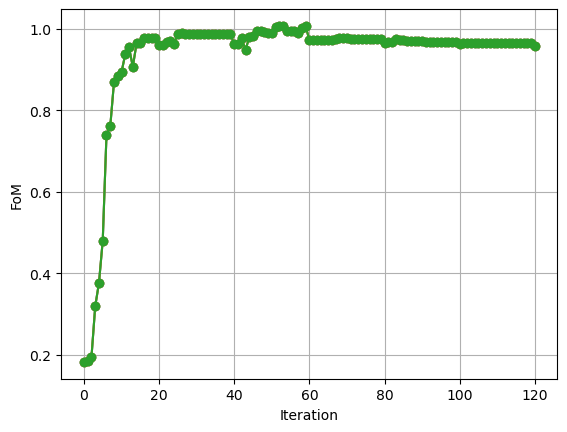

In [10]:
evaluation_history = np.squeeze(evaluation_history)

np.savetxt("evaluation.txt", evaluation_history)
# FoM plot

plt.figure()

plt.plot(evaluation_history, "o-")
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("FoM")
plt.savefig("FoMresult.png")
plt.show()

최적화 검증

디렉토리 이미 존재합니다: blue print


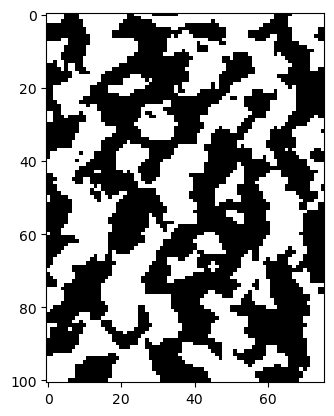

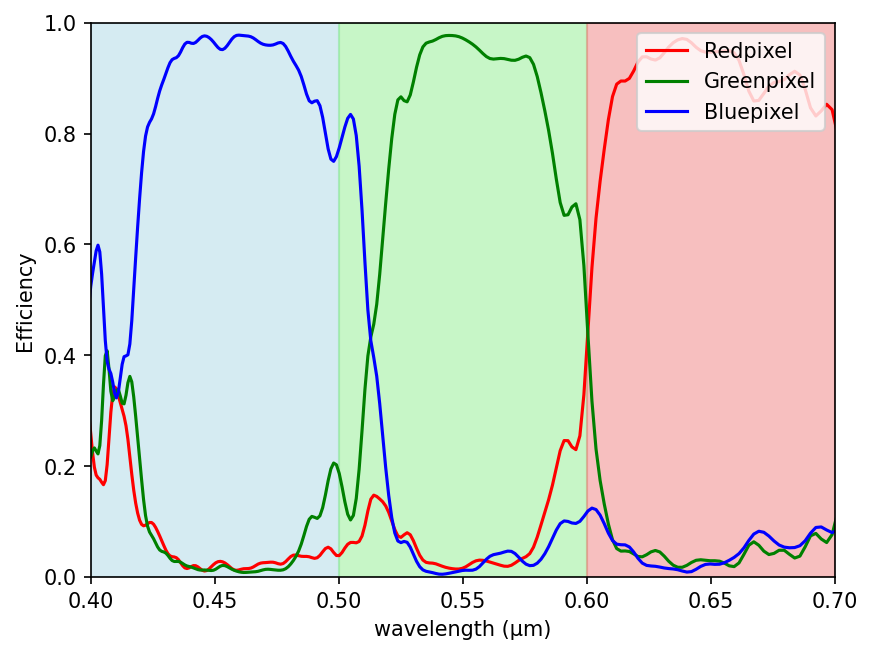

T_red: 0.9713433877998999

T_green: 0.9769636747369081

T_blue: 0.977547119764993

Optical crosstalk: 0.15135511110889702

Color filter contrast: 0.9648443054954224

디렉토리 이미 존재합니다: dilation


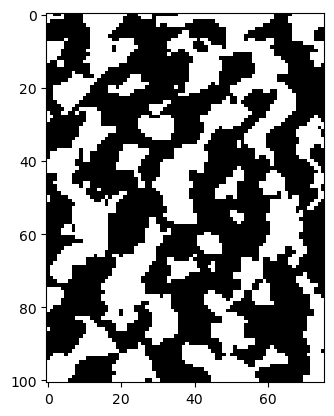

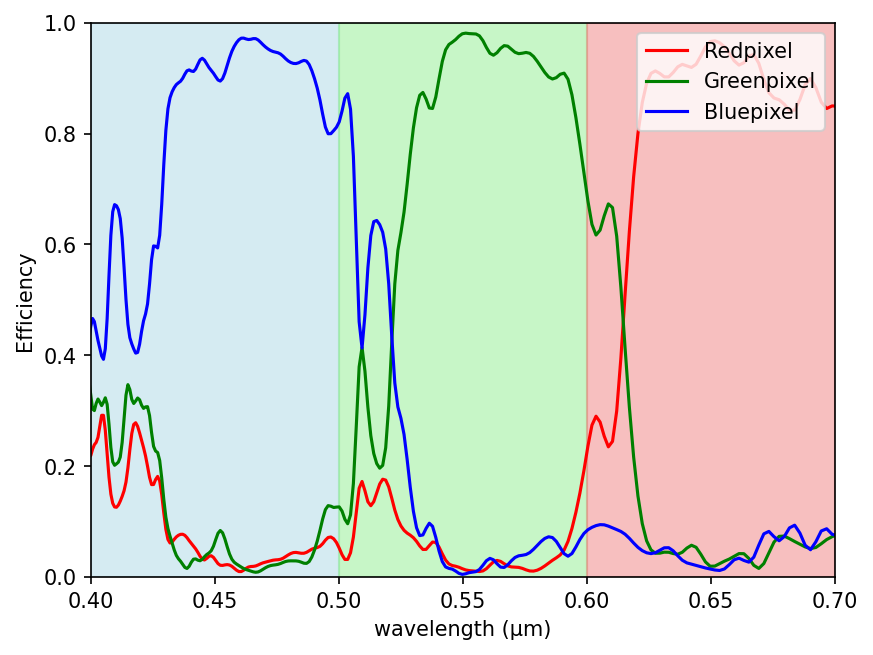

T_red: 0.9673835733534825

T_green: 0.9811211563645922

T_blue: 0.9721702516358044

Optical crosstalk: 0.14866059462183528

Color filter contrast: 0.9690830368259716

디렉토리 이미 존재합니다: erosion


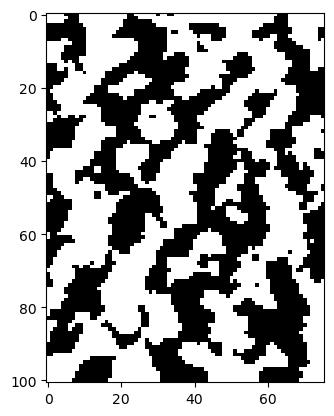

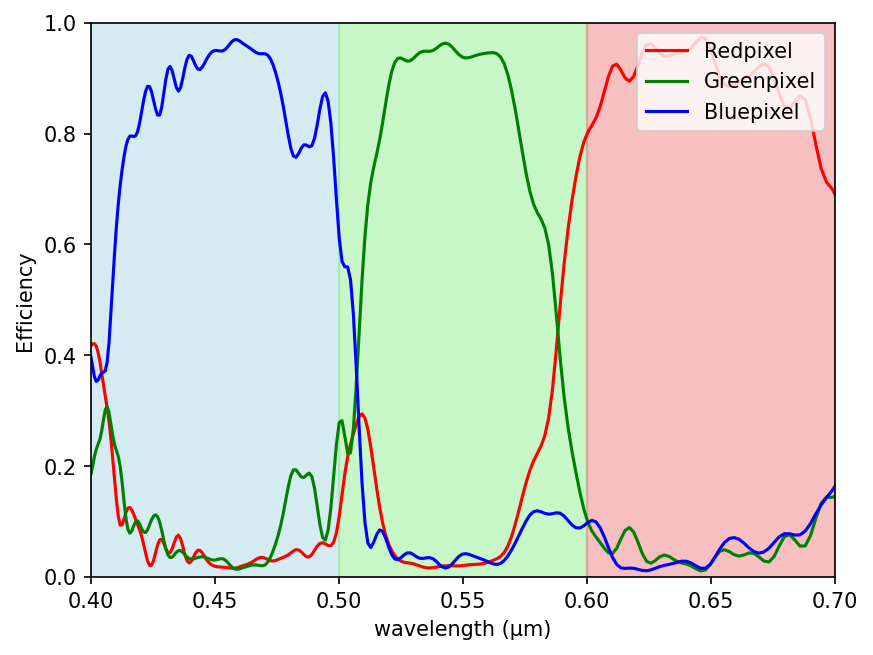

T_red: 0.9729489093606691

T_green: 0.9631854559335598

T_blue: 0.9695285624861679

Optical crosstalk: 0.16085255223779085

Color filter contrast: 0.957037983858659

Dilation Error Rate (Red): 0.41%
Dilation Error Rate (Green): 0.43%
Dilation Error Rate (Blue): 0.55%
Erosion Error Rate (Red): 0.17%
Erosion Error Rate (Green): 1.41%
Erosion Error Rate (Blue): 0.82%


In [9]:
import os

design = [0,1,2]

def make_dir(d):
    if d == 0:
        directory_name = "blue print"
    elif d == 1:
        directory_name = "dilation"
    elif d == 2:
        directory_name = "erosion"
    else:
        print("잘못된 입력입니다.")
        return
    
    try:
        if not os.path.exists(directory_name):
            os.makedirs(directory_name)
            print("디렉토리 생성 성공:", directory_name)
        else:
            print("디렉토리 이미 존재합니다:", directory_name)
    except Exception as e:
        print("디렉토리 생성 중 오류 발생:", e)

# 초기값 설정
reference_red, reference_green, reference_blue = None, None, None
dilation_red, dilation_green, dilation_blue = None, None, None
erosion_red, erosion_green, erosion_blue = None, None, None

for d in design:
    make_dir(d)
    if d == 0:
        directory_name = "blue print"
    elif d == 1:
        directory_name = "dilation"
    elif d == 2:
        directory_name = "erosion"

    # 디자인 불러오기
    structure_weight = np.loadtxt('v.txt')

    structure_weight = mpa.conic_filter(
            structure_weight,
            0.08,
            design_region_width,
            design_region_height,
            resolution,
        )
    
    if d == 0:
        structure_weight = mpa.tanh_projection(structure_weight, mp.inf, 0.5)
    elif d == 1:
        structure_weight = mpa.tanh_projection(structure_weight, mp.inf, 0.45)
    elif d == 2:
        structure_weight = mpa.tanh_projection(structure_weight, mp.inf, 0.55)

    # 설계 영역과 물질을 바탕으로 설계 영역 설정
    design_variables = mp.MaterialGrid(mp.Vector3(Nx, Ny), SiO2, SiN, grid_type="U_MEAN")

    design_variables.update_weights(structure_weight)

    design_region = mpa.DesignRegion(
        design_variables,
        volume=mp.Volume(
            center=mp.Vector3(0, 0, 0),
            size=mp.Vector3(design_region_width, design_region_height, 0),
        ),
    )

    plt.imshow(npa.rot90(design_variables.weights.reshape(Nx, Ny)), cmap='binary')
    plt.savefig("./"+directory_name+"/lastdesign.png", bbox_inches='tight')

    # design region과 동일한 size의 Block 생성
    geometry = [
        mp.Block(
            center=design_region.center, size=design_region.size, material=design_variables
        ),
        mp.Block(
            center=mp.Vector3(0, -3, 0), size=mp.Vector3(Sx, 2, 0), material=SiPD
        ),
    ]

    
    fcen = (1/(0.38 * um_scale) + 1/(0.78 * um_scale))/2
    df = 1 /(0.38 * um_scale) - 1/(0.78 * um_scale)
    nfreq = 300

    src = mp.GaussianSource(frequency=fcen, fwidth=df, is_integrated=True)
    source = [mp.Source(src, component=mp.Ez, size=source_size, center=source_center)]

    # Meep simulation 세팅
    sim = mp.Simulation(
        cell_size=cell_size, # cell_size = mp.Vector3(Sx, Sy)
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=source,
        default_material=Air, # 빈공간
        resolution=resolution,
        k_point = k_point_0
    )

    opt = mpa.OptimizationProblem(
        simulation=sim,
        objective_functions=[J],
        objective_arguments=ob_list,
        design_regions=[design_region],
        frequencies=frequencies,
        decay_by=1e-3,
    )

    # Transmission spectrum
    opt.sim.reset_meep()
    geometry_1 = [
        mp.Block(
            center=mp.Vector3(0, 0, 0), size=mp.Vector3(Sx, Sy, 0), material=Air
        )
    ]

    opt.sim = mp.Simulation(
        cell_size=mp.Vector3(Sx, Sy),
        boundary_layers=pml_layers,
        geometry=geometry_1,
        sources=source,
        default_material=Air,
        resolution=resolution,
        k_point = mp.Vector3(0,0,0)
    )

    tran_t = mp.FluxRegion(
        center=mp.Vector3(0, -Sy/2 + pml_size + 0.5 - 0.5/resolution, 0), size=mp.Vector3(Sx, 0, 0)
    )
    tran_total = opt.sim.add_flux(fcen, df, nfreq, tran_t)

    refl_fr = mp.FluxRegion(
        center=mp.Vector3(0, Sy/2 - pml_size - 0.5/resolution, 0), size=mp.Vector3(Sx, 0, 0)
    ) 
    refl = opt.sim.add_flux(fcen, df, nfreq, refl_fr)

    pt = mp.Vector3(1, -Sy/2 + pml_size + 0.5/resolution, 0) #pt는 transmitted flux region과 동일


    opt.sim.run(until_after_sources=mp.stop_when_fields_decayed(10,mp.Ez,pt,1e-3))

    straight_refl_data = sim.get_flux_data(refl)
    total_flux = mp.get_fluxes(tran_total)
    flux_freqs = mp.get_flux_freqs(tran_total)

    opt.sim.reset_meep()

    opt.sim = mp.Simulation(
        cell_size=mp.Vector3(Sx, Sy),
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=source,
        default_material=Air,
        resolution=resolution,
        k_point = mp.Vector3(0,0,0)
    )

    fcen = (1/(0.38 * um_scale) + 1/(0.78 * um_scale))/2
    df = 1 /(0.38 * um_scale) - 1/(0.78 * um_scale)

    src = mp.GaussianSource(frequency=fcen, fwidth=df, is_integrated=True)
    source = [mp.Source(src, component=mp.Ez, size=source_size, center=source_center)]
    opt.sim.change_sources(source)

    # 반사된 flux 구하기

    refl = opt.sim.add_flux(fcen, df, nfreq, refl_fr)

    # 투과된 flux 구하기

    tran_fr = mp.FluxRegion(
        center=mp.Vector3(0, -2 - 0.5/resolution, 0), size=mp.Vector3(Sx, 0, 0)
    )
    tran = opt.sim.add_flux(fcen, df, nfreq, tran_fr)

    #반사된 필드와 입사되는 필드를 구분하기 위해서 The Fourier-transformed incident fields을
    #the Fourier transforms of the scattered fields 에서 빼줍니다.
    sim.load_minus_flux_data(refl, straight_refl_data)

    tran_r = mp.FluxRegion(
        center=mp.Vector3(-1, -2 - 0.5/resolution, 0), size=mp.Vector3(1, 0, 0)
    )
    tran_g = mp.FluxRegion(
        center=mp.Vector3(0, -2 - 0.5/resolution, 0), size=mp.Vector3(1, 0, 0)
    )
    tran_b = mp.FluxRegion(
        center=mp.Vector3(1, -2 - 0.5/resolution, 0), size=mp.Vector3(1, 0, 0)
    )
    nfreq = 300
    tran_red = opt.sim.add_flux(fcen, df, nfreq, tran_r)
    tran_green = opt.sim.add_flux(fcen, df, nfreq, tran_g)
    tran_blue = opt.sim.add_flux(fcen, df, nfreq, tran_b)

    pt = mp.Vector3(1, -Sy/2 + pml_size + 0.5/resolution , 0) #pt는 transmitted flux region과 동일

    opt.sim.run(until_after_sources=mp.stop_when_fields_decayed(10,mp.Ez,pt,1e-3))

    red_flux = mp.get_fluxes(tran_red)
    green_flux = mp.get_fluxes(tran_green)
    blue_flux = mp.get_fluxes(tran_blue)

    refl_flux = mp.get_fluxes(refl)
    tran_flux = mp.get_fluxes(tran)

    wl = []
    Tr = []
    Tg = []
    Tb = []

    for i in range(nfreq):
        wl = np.append(wl, 1 / (flux_freqs[i] * um_scale))
        Tr = np.append(Tr, red_flux[i] / tran_flux[i] )
        Tg = np.append(Tg, green_flux[i] / tran_flux[i] )
        Tb = np.append(Tb, blue_flux[i] / tran_flux[i] )


    if mp.am_master():
        plt.figure(dpi=150)
        plt.plot(wl, Tr, "r", label="Redpixel")
        plt.plot(wl, Tg, "g", label="Greenpixel")
        plt.plot(wl, Tb, "b", label="Bluepixel")

        
        plt.axis([0.40, 0.70, 0, 1])
        plt.xlabel("wavelength (μm)")
        plt.ylabel("Efficiency")
        plt.fill([0.40, 0.40, 0.50, 0.50], [0.0, 1.0, 1.0, 0.0], color='lightblue', alpha=0.5)
        plt.fill([0.50, 0.50, 0.60, 0.60], [0.0, 1.0, 1.0, 0.0], color='lightgreen', alpha=0.5)
        plt.fill([0.60, 0.60, 0.70, 0.70], [0.0, 1.0, 1.0, 0.0], color='lightcoral', alpha=0.5)
        plt.legend(loc="upper right")
        plt.savefig("./"+directory_name+"/OpticalEfficiency.png")
        plt.show()


    print(f"T_red: {max(Tr)}\n")
    print(f"T_green: {max(Tg)}\n")
    print(f"T_blue: {max(Tb)}\n")

    np.savetxt("./"+directory_name+"/T_red.txt", Tr)
    np.savetxt("./"+directory_name+"/T_green.txt", Tg)
    np.savetxt("./"+directory_name+"/T_blue.txt", Tb)

    if d == 0:
        reference_red = max(Tr)
        reference_green = max(Tg)
        reference_blue = max(Tb)
    elif d == 1:
        dilation_red = max(Tr)
        dilation_green = max(Tg)
        dilation_blue = max(Tb)
    elif d == 2:
        erosion_red = max(Tr)
        erosion_green = max(Tg)
        erosion_blue = max(Tb)

    with open("./"+directory_name+"/transmittance_summary.txt", "w") as f:
        f.write(f"T_red: {max(Tr)}\n")
        f.write(f"T_green: {max(Tg)}\n")
        f.write(f"T_blue: {max(Tb)}\n")
        f.write(f"T_red_mean: {np.mean((Tr)[0:66])}\n")
        f.write(f"T_green_mean: {np.mean((Tg)[66:160])}\n")
        f.write(f"T_blue_mean: {np.mean((Tb)[160:300])}\n")
    
    # Calculate crosstalk
    crosstalk_r_g = np.mean((Tg)[0:66])
    crosstalk_r_b = np.mean((Tb)[0:66])
    crosstalk_g_b = np.mean((Tb)[66:160])
    crosstalk_g_r = np.mean((Tr)[66:160]) 
    crosstalk_b_r = np.mean((Tr)[160:300]) 
    crosstalk_b_g = np.mean((Tg)[160:300])

    crosstalk_avg = (crosstalk_r_g + crosstalk_r_b + crosstalk_g_b + crosstalk_g_r + crosstalk_b_r + crosstalk_b_g) / 6

    print(f"Optical crosstalk: {crosstalk_avg}\n")

    # Save crosstalk values to a file
    with open("./"+directory_name+"/crosstalk_summary.txt", "w") as f:
        f.write(f"crosstalk_r_g: {crosstalk_r_g}\n")
        f.write(f"crosstalk_r_b: {crosstalk_r_b}\n")
        f.write(f"crosstalk_g_b: {crosstalk_g_b}\n")
        f.write(f"crosstalk_g_r: {crosstalk_g_r}\n")
        f.write(f"crosstalk_b_r: {crosstalk_b_r}\n")
        f.write(f"crosstalk_b_g: {crosstalk_b_g}\n")
        f.write(f"crosstalk_avg: {crosstalk_avg}\n")

    I_red = Tr
    I_green = Tg
    I_blue = Tb

    # color filter contrast 계산 함수
    def calculate_contrast(I_red, I_green, I_blue):
        # 각 파장에서 R, G, B 중에서 가장 큰 값과 두 번째로 큰 값을 계산
        RGB_values = np.stack((I_red, I_green, I_blue), axis=1)
        max_values = np.max(RGB_values, axis=1)  # 각 파장에서 최대값
        second_max_values = np.partition(RGB_values, -2, axis=1)[:, -2]  # 두 번째로 큰 값
        return max_values - second_max_values

    # 각 파장에 대해 color filter contrast 계산
    contrast_values = calculate_contrast(I_red, I_green, I_blue)

    # color filter contrast의 최대값 계산
    max_contrast = np.max(contrast_values)

    # 최대 contrast가 발생한 파장 찾기
    max_contrast_wavelength = 1/((fcen - (df / 2) + (np.argmax(contrast_values) / nfreq) * df)* um_scale)

    print(f"Color filter contrast: {max_contrast}\n")

    # Save contrast values to a file
    with open("./"+directory_name+"/contrast_summary.txt", "w") as f:
        f.write(f"max_contrast: {max_contrast}\n")
        f.write(f"max_contrast_wavelength: {max_contrast_wavelength}\n")

dilation_error_red = np.abs(dilation_red - reference_red) / reference_red * 100
dilation_error_green = np.abs(dilation_green - reference_green) / reference_green * 100
dilation_error_blue = np.abs(dilation_blue - reference_blue) / reference_blue * 100

erosion_error_red = np.abs(erosion_red - reference_red) / reference_red * 100
erosion_error_green = np.abs(erosion_green - reference_green) / reference_green * 100
erosion_error_blue = np.abs(erosion_blue - reference_blue) / reference_blue * 100

print(f"Dilation Error Rate (Red): {dilation_error_red:.2f}%")
print(f"Dilation Error Rate (Green): {dilation_error_green:.2f}%")
print(f"Dilation Error Rate (Blue): {dilation_error_blue:.2f}%")

print(f"Erosion Error Rate (Red): {erosion_error_red:.2f}%")
print(f"Erosion Error Rate (Green): {erosion_error_green:.2f}%")
print(f"Erosion Error Rate (Blue): {erosion_error_blue:.2f}%")
